# Topic Classification with a Feedforward Network

### Gameplan

- Text processing methods for transforming raw text data into input vectors.


- A Feedforward network consisting of:
    - **One-hot** input layer mapping words into an **Embedding weight matrix**
    - **One hidden layer** computing the mean embedding vector of all words in input followed by a **ReLU activation function**
    - **Output layer** with a **softmax** activation


- The Stochastic Gradient Descent (SGD) algorithm with **back-propagation** to learn the weights of the Neural network.
    - Use (and minimise) the **Categorical Cross-entropy loss** function 
    - Perform a **Forward pass** to compute intermediate outputs
    - Perform a **Backward pass** to compute gradients and update all sets of weights 
    - Implement and use **Dropout** after each hidden layer for regularisation


- Re-train the network by using pre-trained embeddings ([GloVe](https://nlp.stanford.edu/projects/glove/)) trained on large corpora. 


### Data

Subset of the [AG News Corpus](http://groups.di.unipi.it/~gulli/AG_corpus_of_news_articles.html) and you can find it in the `./data_topic` folder in CSV format:

- `data_topic/train.csv`: contains 2,400 news articles, 800 for each class to be used for training.
- `data_topic/dev.csv`: contains 150 news articles, 50 for each class to be used for hyperparameter selection and monitoring the training process.
- `data_topic/test.csv`: contains 900 news articles, 300 for each class to be used for testing.

### Pre-trained Embeddings

You can download pre-trained GloVe embeddings trained on Common Crawl (840B tokens, 2.2M vocab, cased, 300d vectors, 2.03 GB download) from [here](http://nlp.stanford.edu/data/glove.840B.300d.zip). No need to unzip, the file is large.

### Save Memory

To save RAM, when we finish each experiment we delete the weights of your network using `del W` followed by Python's garbage collector `gc.collect()`

In [1]:
# Imports

import pandas as pd
import numpy as np
from collections import Counter
import re
import matplotlib.pyplot as plt
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import random
from time import localtime, strftime
from scipy.stats import spearmanr,pearsonr
import zipfile
import gc

# fixing random seed for reproducibility
random.seed(123)
np.random.seed(123)

## Transform Raw texts into training and development data

Load the training, development and test sets from their corresponding CSV files

In [11]:
# Loading input data and naming the 2 columns

train_df = pd.read_csv("../data_topic/train.csv",names=["label","text"])
dev_df = pd.read_csv("../data_topic/dev.csv",names=["label","text"])
test_df = pd.read_csv("../data_topic/test.csv",names=["label","text"])

In [12]:
#trainsform the df to list
train_text = list(train_df['text'])
dev_text = list(dev_df['text'])
test_text = list(test_df['text'])

train_label = np.array(train_df['label'])
dev_label = np.array(dev_df['label'])
test_label = np.array(test_df['label'])

In [13]:
train_df.head()

,label,text
0,1,Reuters - Venezuelans turned out early\and in ...
1,1,Reuters - South Korean police used water canno...
2,1,Reuters - Thousands of Palestinian\prisoners i...
3,1,AFP - Sporadic gunfire and shelling took place...
4,1,AP - Dozens of Rwandan soldiers flew into Suda...


In [14]:
train_text[:5]

['Reuters - Venezuelans turned out early\\and in large numbers on Sunday to vote in a historic referendum\\that will either remove left-wing President Hugo Chavez from\\office or give him a new mandate to govern for the next two\\years.',
 'Reuters - South Korean police used water cannon in\\central Seoul Sunday to disperse at least 7,000 protesters\\urging the government to reverse a controversial decision to\\send more troops to Iraq.',
 "Reuters - Thousands of Palestinian\\prisoners in Israeli jails began a hunger strike for better\\conditions Sunday, but Israel's security minister said he\\didn't care if they starved to death.",
 'AFP - Sporadic gunfire and shelling took place overnight in the disputed Georgian region of South Ossetia in violation of a fragile ceasefire, wounding seven Georgian servicemen.',
 "AP - Dozens of Rwandan soldiers flew into Sudan's troubled Darfur region Sunday, the first foreign armed force deployed in the area since Arab militiamen began a rampage agai

# Create input representations

Represent documents as lists of vocabulary indices (each word corresponds to a vocabulary index).


## Text Pre-Processing Pipeline

To obtain a vocabulary of words:
- tokenise all texts into a list of unigrams 
- remove stop words
- remove unigrams appearing in less than K documents
- use the remaining to create a vocabulary of the top-N most frequent unigrams in the entire corpus.

In [15]:
stop_words = ['a','in','on','at','and','or',
              'to', 'the', 'of', 'an', 'by',
              'as', 'is', 'was', 'were', 'been', 'be',
              'are','for', 'this', 'that', 'these', 'those', 'you', 'i', 'if',
             'it', 'he', 'she', 'we', 'they', 'will', 'have', 'has',
              'do', 'did', 'can', 'could', 'who', 'which', 'what',
              'but', 'not', 'there', 'no', 'does', 'not', 'so', 've', 'their',
             'his', 'her', 'they', 'them', 'from', 'with', 'its']

### Unigram extraction from a document

Implement the `extract_ngrams` function. It takes as input:
- `x_raw`: a string corresponding to the raw text of a document.
- `ngram_range`: a tuple of two integers denoting the type of ngrams you want to extract, e.g. (1,2) denotes extracting unigrams and bigrams.
- `token_pattern`: a string to be used within a regular expression to extract all tokens. Note that data is already tokenised.
- `stop_words`: a list of stop words.
- `vocab`: a given vocabulary. It should be used to extract specific features.

and returns:

- a list of all extracted features.


In [16]:
def extract_ngrams(x_raw, ngram_range=(1,3), token_pattern=r'\b[A-Za-z][A-Za-z]+\b',stop_words=[], vocab=set()):

    pattern_re = re.compile(token_pattern)

    # Tokenize to get unigrams not in the stop list
    unigrams = [word for word in pattern_re.findall(str(x_raw).lower(),) if word not in stop_words]

    # Initialize the list for all n-grams
    ngrams_total = []

    if ngram_range[0] == 1:
        ngrams_total = unigrams

    # Generate n-grams from unigrams
    xtracted_features = []

    for n in range(ngram_range[0], ngram_range[1] + 1):
        if n == 1: continue

        args = [unigrams] + [unigrams[i:] for i in range(1, n)]

        xngram = list(zip(*args))
        xtracted_features.append(xngram)

    for i in xtracted_features:
        for j in i:
            ngrams_total.append(j)

    if len(vocab) > 0:
        ngrams_total = [word for word in ngrams_total if word in vocab]

    return ngrams_total

### Create a vocabulary of n-grams

Then the `get_vocab` function will be used to (1) create a vocabulary of ngrams; (2) count the document frequencies of ngrams; (3) their raw frequency. It takes as input:
- `X_raw`: a list of strings each corresponding to the raw text of a document
- `ngram_range`: a tuple of two integers denoting the type of ngrams you want to extract, e.g. (1,2) denotes extracting unigrams and bigrams.
- `token_pattern`: a string to be used within a regular expression to extract all tokens. Note that data is already tokenised so you could opt for a simple white space tokenisation.
- `stop_words`: a list of stop words
- `min_df`: keep ngrams with a minimum document frequency.
- `keep_topN`: keep top-N more frequent ngrams.

and returns:

- `vocab`: a set of the n-grams that will be used as features.
- `df`: a Counter (or dict) that contains ngrams as keys and their corresponding document frequency as values.
- `ngram_counts`: counts of each ngram in vocab


In [17]:
def get_vocab(X_raw, ngram_range=(1,3), token_pattern=r'\b[A-Za-z][A-Za-z]+\b', min_df=3, keep_topN=3000, stop_words=[]):

    doc_frequency = Counter()
    ngram_frequency = Counter()
    vocabulary = set()

    # Loop through each text to calculate frequencies
    for text in X_raw:
        ngrams = extract_ngrams(text, ngram_range, token_pattern, stop_words)
        doc_frequency.update(list(set(ngrams)))
        ngram_frequency.update(ngrams)

    # Create vocabulary based on minimum document frequency
    vocabulary = set([i for i in doc_frequency if doc_frequency[i] >= min_df])

    # Optionally keep top N ngrams
    if keep_topN > 0:
        vocabulary = set([i[0] for i in ngram_frequency.most_common(keep_topN) if i[0] in vocabulary])

    return vocabulary, doc_frequency, ngram_frequency

In [18]:
vocab,df,ngram_counts = get_vocab(train_text, ngram_range=(1,3), min_df = 1, keep_topN=3000, stop_words=stop_words)
vocab_dev, df_dev, ngram_counts_dev = get_vocab(dev_text, ngram_range=(1,3), min_df = 1, keep_topN=3000, stop_words=stop_words)
vocab_test, df_test, ngram_counts_test = get_vocab(test_text, ngram_range=(1,3), min_df = 1, keep_topN=3000, stop_words=stop_words)

print("Vocab: \n", list(vocab)[:50])
print("\n Raw frequencies of n-grams: \n", df.most_common()[:10])
print("\n Counts of each ngram in vocab \n", ngram_counts.most_common()[:10])

Vocab: 
 [('recall', 'referendum'), ('john', 'paul', 'ii'), 'mason', 'officials', 'continued', 'thanks', ('western', 'burundi'), 'psychological', ('miss', 'season'), 'hand', 'may', ('kostas', 'kenteris'), 'defensive', 'minutes', 'herat', ('quarterly', 'profit'), ('kosuke', 'kitajima'), ('york', 'reuters', 'stocks'), 'palestinians', 'mariel', 'ninth', 'rangers', 'bay', 'disruptions', ('reuters', 'oil', 'prices'), 'heat', 'image', 'calling', 'commit', ('world', 'largest'), ('department', 'store'), ('last', 'month'), ('stock', 'exchange'), ('golf', 'club'), 'chief', 'hitter', 'wife', 'sweeping', 'assembly', ('aug', 'xinhuanet'), 'fre', 'helicopter', ('collective', 'bargaining'), 'potential', ('half', 'year'), 'lost', 'growth', 'billions', 'against', 'speed']

 Raw frequencies of n-grams: 
 [('reuters', 631), ('said', 432), ('tuesday', 413), ('wednesday', 344), ('new', 325), ('after', 295), ('ap', 275), ('athens', 245), ('monday', 221), ('first', 210)]

 Counts of each ngram in vocab 
 [('

Create vocabulary id -> word and word -> vocabulary id dictionaries for reference:
id_to_word & word_to_id

In [19]:
def transformation(vocab):
    # Create word to vocabulary ID mapping
    id_to_word = dict(enumerate(vocab))
    # Create vocabulary ID to word mapping
    word_to_id = {word: idx for idx, word in id_to_word.items()}

    return id_to_word, word_to_id

id2word_train, word2id_train = transformation(vocab)

In [20]:
for key, value in list(id2word_train.items())[:5]:
    print(f"{key}: {value}")

0: ('recall', 'referendum')
1: ('john', 'paul', 'ii')
2: mason
3: officials
4: continued


In [21]:
for key, value in list(word2id_train.items())[:5]:
    print(f"{key}: {value}")

('recall', 'referendum'): 0
('john', 'paul', 'ii'): 1
mason: 2
officials: 3
continued: 4


In [22]:
print("Vocabulary sample:")
print(list(word2id_train.items())[:5])

print("Raw text:")
print(train_text[0])

print("Extracted ngrams:")
print(extract_ngrams(train_text[0])[:5])

Vocabulary sample:
[(('recall', 'referendum'), 0), (('john', 'paul', 'ii'), 1), ('mason', 2), ('officials', 3), ('continued', 4)]
Raw text:
Reuters - Venezuelans turned out early\and in large numbers on Sunday to vote in a historic referendum\that will either remove left-wing President Hugo Chavez from\office or give him a new mandate to govern for the next two\years.
Extracted ngrams:
['reuters', 'venezuelans', 'turned', 'out', 'early']


### Convert the list of unigrams  into a list of vocabulary indices

Storing actual one-hot vectors into memory for all words in the entire data set is prohibitive. Instead, we will store word indices in the vocabulary and look-up the weight matrix. This is equivalent of doing a dot product between an one-hot vector and the weight matrix.

First, represent documents in train, dev and test sets as lists of words in the vocabulary:

In [23]:
def uni_indices(vocabulary, word2id):

    # Create an empty list to store the indices for each word in the vocabulary
    indices_list = []
    unique_words = list(vocabulary)

    # Loop through each word in the vocabulary
    for word_id in range(len(unique_words)):
        list_vocab = []

        words = extract_ngrams(unique_words[word_id])

        # Check if each word has a corresponding ID in the mapping and collect the IDs
        for word in words:
            if word in word2id:
                id = word2id[word]
                list_vocab.append(id)
        indices_list.append(list_vocab)
    return unique_words, indices_list

# Apply the function to the train dataset
unique_texts, indice_list = uni_indices(train_text, word2id_train)
print("Processed words:")
print(unique_texts[10][:10])

print("Indices:")
print(indice_list[10][:10])

Processed words:
AFP - Alth
Indices:
[1935, 1419, 372, 2843, 1005, 2783, 1939, 25, 474, 241]


Then convert them into lists of indices in the vocabulary:

In [24]:
# prcessing all document make vocab
vocab_train, vocab_dev, vocab_test = [],[],[]
for text in train_text:
    vocab_train.append(extract_ngrams(text, ngram_range=(1,3),stop_words=stop_words))
for text in dev_text:
    vocab_dev.append(extract_ngrams(text, ngram_range=(1,3),stop_words=stop_words))
for text in test_text:
    vocab_test.append(extract_ngrams(text, ngram_range=(1,3),stop_words=stop_words))

train_unigram,train_indices = uni_indices(vocab_train,word2id_train)
dev_unigram,dev_indices = uni_indices(vocab_dev,word2id_train)
test_unigram,test_indices = uni_indices(vocab_test,word2id_train)

print("Processed words:")
print(train_unigram[15][:110])

print("Indices:")
print(train_indices[150][:110])

Processed words:
['clashes', 'between', 'us', 'troops', 'sadr', 'militiamen', 'escalated', 'thursday', 'us', 'surrounded', 'najaf', 'possible', 'siege', ('clashes', 'between'), ('between', 'us'), ('us', 'troops'), ('troops', 'sadr'), ('sadr', 'militiamen'), ('militiamen', 'escalated'), ('escalated', 'thursday'), ('thursday', 'us'), ('us', 'surrounded'), ('surrounded', 'najaf'), ('najaf', 'possible'), ('possible', 'siege'), ('clashes', 'between', 'us'), ('between', 'us', 'troops'), ('us', 'troops', 'sadr'), ('troops', 'sadr', 'militiamen'), ('sadr', 'militiamen', 'escalated'), ('militiamen', 'escalated', 'thursday'), ('escalated', 'thursday', 'us'), ('thursday', 'us', 'surrounded'), ('us', 'surrounded', 'najaf'), ('surrounded', 'najaf', 'possible'), ('najaf', 'possible', 'siege')]
Indices:
[1642, 2994, 1552, 2900, 1561, 59, 1293, 1338, 157, 160, 2370, 1456, 1320, 700, 414, 2016, 2397, 1798, 1486, 2834, 1642, 2994, 2994, 1552, 1552, 2900, 2900, 1561, 1561, 59, 59, 1293, 1293, 1338, 1338,

In [25]:
def preprocess_and_pad(data, labels):

    final_label = []
    final_data = []

    # Filter out empty documents and corresponding labels
    filtered_data = [d for d in data if d]
    filtered_labels = [labels[i] for i, d in enumerate(data) if d]

    # Calculate maximum length of the documents
    max_length = max(len(doc) for doc in filtered_data)
    print("Max length of each sentence: ", max_length)

    # Pad shorter documents with zeros
    padded_data = [doc + [0] * (max_length - len(doc)) for doc in filtered_data]

    # Ensure the lengths of labels and data are compatible
    for i in range(len(padded_data)):
        if len(padded_data[i])==0:
            continue
        else:
            final_data.append(padded_data[i])
            final_label.append(filtered_labels[i])

    return final_data, np.array(final_label)


X_tr,train_label = preprocess_and_pad(train_indices,train_label)
X_dev,dev_label = preprocess_and_pad(dev_indices,dev_label)
X_te,test_label = preprocess_and_pad(test_indices,test_label)

Max length of each sentence:  526
Max length of each sentence:  285
Max length of each sentence:  536


In [26]:
def list_shape(lst):
    if isinstance(lst, list):
        return [len(lst)] + list_shape(lst[0]) if lst else [0]
    else:
        return []

print("Shape of the list:", list_shape(X_tr))

Shape of the list: [2400, 526]


Put the labels `Y` for train, dev and test sets into arrays:

In [27]:
Y_tr = train_label
Y_dev = dev_label
Y_te = test_label

# Network Architecture

The network should pass each word index into its corresponding embedding by looking-up on the embedding matrix and then compute the first hidden layer $\mathbf{h}_1$:

$$\mathbf{h}_1 = \frac{1}{|x|}\sum_i W^e_i, i \in x$$

where $|x|$ is the number of words in the document and $W^e$ is an embedding matrix $|V|\times d$, $|V|$ is the size of the vocabulary and $d$ the embedding size.

Then $\mathbf{h}_1$ should be passed through a ReLU activation function:

$$\mathbf{a}_1 = relu(\mathbf{h}_1)$$

Finally the hidden layer is passed to the output layer:


$$\mathbf{y} = \text{softmax}(\mathbf{a}_1W) $$
where $W$ is a matrix $d \times |{\cal Y}|$, $|{\cal Y}|$ is the number of classes.

During training, $\mathbf{a}_1$ should be multiplied with a dropout mask vector (elementwise) for regularisation before it is passed to the output layer.

Can also extend to a deeper architecture by passing a hidden layer to another one:

$$\mathbf{h_i} = \mathbf{a}_{i-1}W_i $$

$$\mathbf{a_i} = relu(\mathbf{h_i}) $$



# Network Training

First we need to define the parameters of our network by initiliasing the weight matrices. For that purpose, we implement the `network_weights` function that takes as input:

- `vocab_size`: the size of the vocabulary
- `embedding_dim`: the size of the word embeddings
- `hidden_dim`: a list of the sizes of any subsequent hidden layers. Empty if there are no hidden layers between the average embedding and the output layer
- `num_classes`: the number of the classes for the output layer

and returns:

- `W`: a dictionary mapping from layer index (e.g. 0 for the embedding matrix) to the corresponding weight matrix initialised with small random numbers (hint: use numpy.random.uniform with from -0.1 to 0.1)

Making sure that the dimensionality of each weight matrix is compatible with the previous and next weight matrix, otherwise we won't be able to perform forward and backward passes. 

PS: Consider using np.float32 precision to save memory.

In [28]:
def network_weights(vocab_size=3000, embedding_dim=70,
                    hidden_dim=[100], num_classes=3, init_val = 0.1):

    weights = {}
    '''{
        0: embedding_matrix,
        1: hidden_layer_matrix,
        2: output_matrix
    }'''

    # Initialize weights for the embedding layer
    weights[0] = np.random.uniform(low=-init_val, high=init_val, size=(vocab_size, embedding_dim)).astype(np.float32)

    # Initialize weights for hidden layers
    input_dim = embedding_dim
    for i, dim in enumerate(hidden_dim, 1):
        weights[i] = np.random.uniform(low=-init_val, high=init_val, size=(input_dim, dim)).astype(np.float32)
        input_dim = dim

    # Initialize weights for the output layer
    weights[len(hidden_dim) + 1] = np.random.uniform(low=-init_val, high=init_val, size=(input_dim, num_classes)).astype(np.float32)

    return weights

# Example usage
W = network_weights(vocab_size=3000, embedding_dim=70, hidden_dim=[100], num_classes=3, init_val=0.1)
for k, v in W.items():
    print(f"Layer {k} weights shape: {v.shape}")


Layer 0 weights shape: (3000, 70)
Layer 1 weights shape: (70, 100)
Layer 2 weights shape: (100, 3)


# Softmax Function

It takes as input `z` (array of real numbers) and returns `sig` (the softmax of `z`)

In [29]:
def softmax(z):
    e_z = np.exp(z-np.max(z))
    val = e_z / np.sum(e_z)
    return val

# Categorical cross entropy loss

In [30]:
def categorical_loss(y, y_preds):
    l = -np.log(y_preds[y])
    return l

# ReLU

Implement the `relu` function to introduce non-linearity after each hidden layer of your network
(during the forward pass):

$$relu(z_i)= max(z_i,0)$$

and the `relu_derivative` function to compute its derivative (used in the backward pass):

  
  relu_derivative($z_i$)=0, if $z_i$<=0, 1 otherwise.
  

In [31]:
def relu(z):
    z = z.copy()
    a = np.maximum(0, z)
    return a

def relu_derivative(z):
    dz = z.copy()
    dz[dz <= 0] = 0
    dz[dz > 0] = 1
    return dz

# Dropout Mask

During training we apply a dropout mask element-wise after the activation function (i.e. vector of ones with a random percentage set to zero). The `dropout_mask` function takes as input:

- `size`: the size of the vector that we want to apply dropout
- `dropout_rate`: the percentage of elements that will be randomly set to zeros

and returns:

- `dropout_vec`: a vector with binary values (0 or 1)

In [32]:
def dropout_mask(size, dropout_rate):
    # Initialize a vector of 1
    dropout_vec = np.ones(size)

    dropout_vec[:int(size*dropout_rate)] = 0.0
    np.random.shuffle(dropout_vec)
    return dropout_vec


In [33]:
print(dropout_mask(10, 0.2))
print(dropout_mask(10, 0.2))

[1. 1. 1. 1. 0. 1. 1. 0. 1. 1.]
[1. 1. 1. 0. 1. 1. 0. 1. 1. 1.]


In [ ]:
# Sample Input

weighted_input = []
for i in X_tr:
    weighted_input.append(W[0][i])

print("Weighted input shape:", np.array(weighted_input).shape)
print("Weighted input sample:", np.array(weighted_input)[0][:5])

# Forward Pass

Now we implement the `forward_pass` function that passes the input x through the network up to the output layer for computing the probability for each class using the weight matrices in `W`. The ReLU activation function should be applied on each hidden layer.

- `x`: a list of vocabulary indices each corresponding to a word in the document (input)
- `W`: a list of weight matrices connecting each part of the network, e.g. for a network with a hidden and an output layer: W[0] is the weight matrix that connects the input to the first hidden layer, W[1] is the weight matrix that connects the hidden layer to the output layer.
- `dropout_rate`: the dropout rate that is used to generate a random dropout mask vector applied after each hidden layer for regularisation.

and returns:

- `out_vals`: a dictionary of output values from each layer: h (the vector before the activation function), a (the resulting vector after passing h from the activation function), its dropout mask vector; and the prediction vector (probability for each class) from the output layer.

In [35]:
def forward_pass(x, W, dropout_rate=0.2):

    # Initialize lists
    processed_values = {}
    hidden_states = []
    activated_states = []
    dropout_masks = []
    num_layers = len(W) - 1

    # Processing input
    weighted_input = []
    input_length = len(x)

    # Assign initial layer
    for i in x:
        weighted_input.append(W[0][i])

    hidden_sum = np.sum(weighted_input, axis=0)
    hidden_sum = hidden_sum / input_length

    # Applying Relu and dropout mask
    activated_sum = relu(hidden_sum)
    dropout = dropout_mask(len(activated_sum), dropout_rate)
    processed_output = activated_sum * dropout

    hidden_states.append(hidden_sum)
    activated_states.append(activated_sum)
    dropout_masks.append(dropout)

    # Forward pass through layers
    for i in range(1, num_layers):
        hidden_output = np.dot(processed_output, W[i])

        activated_output = relu(hidden_output)
        dropout = dropout_mask(len(activated_output), dropout_rate)
        processed_output = activated_output * dropout
        hidden_states.append(hidden_output)
        activated_states.append(activated_output)
        dropout_masks.append(dropout)

    # Computing final prediction
    prediction = softmax(np.dot(processed_output, W[num_layers]))

    # Storing processed values in dictionary
    processed_values['h'] = hidden_states
    processed_values['a'] = activated_states
    processed_values['dropout_vecs'] = dropout_masks
    processed_values['y'] = prediction

    return processed_values

# Backward Pass

The `backward_pass` function computes the gradients and updates the weights for each matrix in the network from the output to the input. It takes as input

- `x`: a list of vocabulary indices each corresponding to a word in the document (input)
- `y`: the true label
- `W`: a list of weight matrices connecting each part of the network, e.g. for a network with a hidden and an output layer: W[0] is the weight matrix that connects the input to the first hidden layer, W[1] is the weight matrix that connects the hidden layer to the output layer.
- `out_vals`: a dictionary of output values from a forward pass.
- `learning_rate`: the learning rate for updating the weights.
- `freeze_emb`: boolean value indicating whether the embedding weights will be updated.

and returns:

- `W`: the updated weights of the network.

PS: the gradients on the output layer are similar to the multiclass logistic regression.

In [37]:
def backward_pass(x, y, W, out_vals, lr=0.001, freeze_emb=False):
    W_length = len(W)-1
    W0_shape = W[W_length].shape[0]
    W1_shape = W[W_length].shape[1]

    # y is the label array
    # Set the correct class position to 1 and the rest to 0
    y_layer = np.zeros(W[W_length].shape[1])
    y_layer[y - 1] = 1

    # Compute the gradient on output layer
    delta_L = out_vals['y'] - y_layer

    output_val = out_vals['a'][-1] * out_vals['dropout_vecs'][-1]
    output_value = output_val.reshape(W0_shape,1)
    gradient_value = np.dot(output_value,delta_L.reshape(1, W1_shape))

     # Update the temp for layer
    Wk = np.dot(W[W_length],delta_L).reshape(1,W0_shape)
    g = out_vals['dropout_vecs'][W_length-1]
    temp = Wk * g
    
    # Update the W
    W[W_length] = W[W_length] - lr*gradient_value

    for i in range(1, W_length):

        # f'(z) update with activation der
        der_v = relu_derivative(out_vals['h'][W_length-i]).reshape(1,W[W_length+1-i].shape[0])

        # Compute the gradient on output layer
        temp = temp * der_v
        output_v1 = out_vals['a'][W_length-1-i]*out_vals['dropout_vecs'][W_length-1-i]
        output_value = output_v1.reshape(W[W_length-i].shape[0],1)
        gradient_value = np.dot(output_value,temp)
        temp_Wk = np.dot(W[W_length-i],temp.T).reshape(1,W[W_length-i].shape[0])
        temp_g  = out_vals['dropout_vecs'][W_length-1-i]
        temp = temp_Wk*temp_g

        # Calculate the new W
        W[W_length-i] = W[W_length-i] - lr*gradient_value


    # Update the W0 if freeze_emb==false
    if freeze_emb == False:
        x_array = np.zeros([W[0].shape[0],1])
        x_array[x] = 1.0
        lv_1 = relu_derivative(out_vals['h'][0]).reshape(1,W[0].shape[1])
        temp = temp*lv_1
        w_gradient = np.dot(x_array,temp)
        W[0] = W[0] - lr * w_gradient # w[0] not freezze

    return W

# Stochastic Gradient Descent (SGD)

Finally we modify SGD to support back-propagation by using the `forward_pass` and `backward_pass` functions.

The `SGD` function takes as input:

- `X_tr`: array of training data (vectors)
- `Y_tr`: labels of `X_tr`
- `W`: the weights of the network (dictionary)
- `X_dev`: array of development (i.e. validation) data (vectors)
- `Y_dev`: labels of `X_dev`
- `lr`: learning rate
- `dropout`: regularisation strength
- `epochs`: number of full passes over the training data
- `tolerance`: stop training if the difference between the current and previous validation loss is smaller than a threshold
- `freeze_emb`: boolean value indicating whether the embedding weights will be updated (to be used by the backward pass function).
- `print_progress`: flag for printing the training progress (train/validation loss)


and returns:

- `weights`: the weights learned
- `training_loss_history`: an array with the average losses of the whole training set after each epoch
- `validation_loss_history`: an array with the average losses of the whole development set after each epoch

In [36]:
def SGD(X_tr, Y_tr, W, X_dev=[], Y_dev=[], lr=0.001, dropout=0.2, epochs=5, tolerance=0.001, freeze_emb=False, print_progress=True):
    # History of losses for plotting or analysis
    train_losses = []
    valid_losses = []

    # Helper function to calculate the mean loss using categorical cross-entropy
    def calculate_loss(data_X, data_Y, weights, dropout_rate):
        individual_losses = []
        for x, y in zip(data_X, data_Y):
            outputs = forward_pass(x, weights, dropout_rate)
            prediction = outputs['y']
            print(prediction)

            # Calculate loss and collect it for averaging
            current_loss = categorical_loss(y - 1, prediction)
            individual_losses.append(current_loss)
        return np.mean(individual_losses)

    # Main loop for each epoch
    for epoch in range(epochs):
        # Random shuffle of indices for training data
        shuffle_indices = np.random.permutation(len(X_tr))
        X_tr = [X_tr[i] for i in shuffle_indices]
        Y_tr = [Y_tr[i] for i in shuffle_indices]

        # Loop over each data point and update weights
        for x, y in zip(X_tr, Y_tr):
            output_values = forward_pass(x, W, dropout)
            # Update weights based on gradients
            W = backward_pass(x, y, W, output_values, lr, freeze_emb)

        # Record the training and validation losses
        loss_train = calculate_loss(X_tr, Y_tr, W, dropout)
        train_losses.append(loss_train)

        loss_dev = calculate_loss(X_dev, Y_dev, W, dropout)
        valid_losses.append(loss_dev)

        print(f"Epoch {epoch + 1}/{epochs}, Training Loss: {loss_train:.4f}")
        print(f"Epoch {epoch + 1}/{epochs}, Validation Loss: {loss_dev:.4f}")

    return W, train_losses, valid_losses


# Training Loop

Ready to train and evaluate your neural net. First, define network using the `network_weights` function followed by SGD with backprop:

In [ ]:
W = network_weights(vocab_size=len(vocab),
                    embedding_dim = 70,
                    hidden_dim=[],
                    num_classes=3)

W, loss_tr, dev_loss = SGD(X_tr, Y_tr,
                            W,
                            X_dev=X_dev,
                            Y_dev=Y_dev,
                            lr=0.015,
                            dropout=0.2,
                            freeze_emb=False,
                            tolerance=0.01,
                            epochs=20)

Plot the learning process:

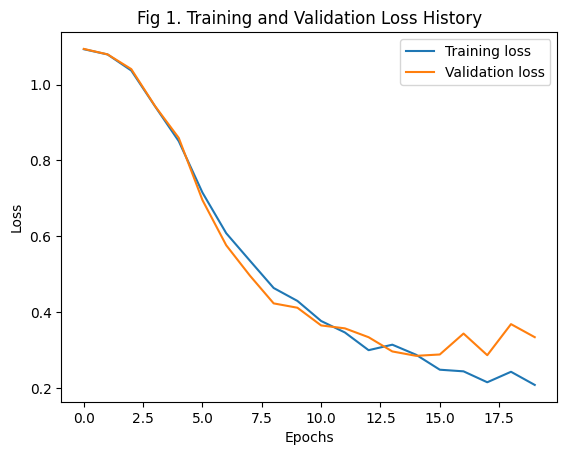

In [39]:
plt.plot(loss_tr, label='Training loss')
plt.plot(dev_loss, label='Validation loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Fig 1. Training and Validation Loss History')
plt.legend()
plt.show()

##### Figure **1** - Training and Validation Loss History
The graph shows a decrease in both training and validation losses as the model adjusts its weights to minimize the error between its predictions and the actual class labels. The slight fluctuations in the validation loss might indicate that the model could start to overfit the training data in later epochs, especially if these fluctuations become more pronounced or if the validation loss starts increasing in subsequent epochs beyond what was captured. By increasing the number of epochs, we can observe only slight improvement in the loss, hence we can continue using smaller epoch cycles.

The training and validation loss curves follow a similar curve trend which means that the lessons it's learning are broadly applicable, not just to the specific examples it's seen but also for unseen data. It is also successfully capturing underlying trends that are true more generally.



Compute accuracy, precision, recall and F1-Score:

In [40]:
preds_te = [np.argmax(forward_pass(x, W, dropout_rate=0.0)['y']) + 1
            for x,y in zip(X_te,Y_te)]
print('Accuracy:', accuracy_score(Y_te,preds_te))
print('Precision:', precision_score(Y_te,preds_te,average='macro'))
print('Recall:', recall_score(Y_te,preds_te,average='macro'))
print('F1-Score:', f1_score(Y_te,preds_te,average='macro'))

Accuracy: 0.8053392658509455
Precision: 0.8332022930196752
Recall: 0.805436640654032
F1-Score: 0.804221009024948


### Discuss how did you choose model hyperparameters ?

The hyperparameters embedding size, learning rate and dropout rate helps us achieve a better result to finetune our model. We uses grid search to get the best parameter that fits our data. By adjusting hyperparameters, you can find a balance between underfitting and overfitting. For example, increasing model complexity might improve training accuracy but can harm generalization to unseen data.

1. Learning rate - The step size should not be too high as it risks overshooting the minimum loss function. But a lower learning rate costs more computational power and takes too long to train. After experimenting with multiple values we find that the learning rate of 0.015 works best for the given data.

2. Embedding size - We experiment over the values 50, 70, 100 sizes. A larger embedding size allows each word to be represented with more features at the risk of overfitting. With 100 size, we find that the model shows a steep decrease in training loss, but struggles to perform well for the validation data. Hence we choose 70 embedding size.  

3. Dropout Rate - Dropout is a technique to drop randomly selected neurons at any time during training. They are temporarily removed in the forward transfer, and any heavy updates will not therefore result in transferring neurons. Out of the dropout rates [0.2, 0.3, 0.4] we find that 0.2 gives the optimal results. during training. They are forever "right to drop out". This means that their contributions to downstream neurons are temporarily removed in the forward transfer, and any heavy updates will not therefore result in transferring neurons.

#### These you MUST set:
- Learning rate
- Number of epochs
- Batch size
- Dropout rate
- Number of layers
- Hidden layer sizes
- Embedding dimension
- Optimizer choice
- Regularization strength

## Test Different Model Hyperparameters


In [ ]:
learning_rate_list = [0.005, 0.01, 0.05]
embedding_size_list = [50, 70]
drop_out_rate_list = [0.2, 0.4]
test_score = []
all_list = []
hyper_list = []

result = []

for dim in embedding_size_list:
    for lr in learning_rate_list:
        for drop in drop_out_rate_list:
            W = network_weights(vocab_size=len(vocab),
                    embedding_dim=dim,
                    hidden_dim=[],
                    num_classes=3,
                    init_val = 0.1)

           # We replace the dim, drop and lr for each iter
            W, loss_tr, dev_loss = SGD(X_tr,Y_tr,W,X_dev=X_dev, Y_dev=Y_dev,lr=lr, dropout = drop,freeze_emb=False,tolerance=0.01,epochs=10,print_progress=True)

            # Results and Scores
            preds_te = [np.argmax(forward_pass(x, W, dropout_rate=0.2)['y'])+1 for x,y in zip(X_te,test_label)]
            accuracy = accuracy_score(test_label,preds_te)
            precision = precision_score(Y_te,preds_te,average='macro')
            Recall =recall_score(Y_te,preds_te,average='macro')
            F_Score =f1_score(Y_te,preds_te,average='macro')
            score = [accuracy, precision, Recall,F_Score]

            current_result = {
                'embedding_dim': dim,
                'learning_rate': lr,
                'dropout_rate': drop,
                'accuracy': accuracy,
                'precision': precision,
                'recall': Recall,
                'f1_score': F_Score
            }
            result.append(current_result)

            test_score.append(accuracy)
            all_list.append([accuracy, precision, Recall, F_Score])
            hyper = [dim, lr, drop]
            hyper_list.append(hyper)


In [28]:
best_result = max(test_score)
best_id = test_score.index(best_result)
best_hyper = hyper_list[best_id]
best_S = all_list[best_id]
print("The best parameter and the F1-score on test set")
print("emb_dim:", best_hyper[0], " lr:", best_hyper[1]," drop_rate:" ,best_hyper[2] ," Accuracy:", best_result, "A/P/R/F",best_S)

The best parameter and the F1-score on test set
emb_dim: 70  lr: 0.05  drop_rate: 0.2  Accuracy: 0.8553948832035595 A/P/R/F [0.8553948832035595, 0.8604630760567672, 0.8553994797473058, 0.8555206505473486]


 | Embediing Size  | Learning Rate  | Drop Rate  | Accuracy
|:-:|:-:|:-:|:-:|
| 300 |0.001| 0.2 |0.8498331479421579   |
| 300 |0.005| 0.2 |0.8531701890989989   |
| 100| 0.05| 0.3  | 0.8576195773081201 |
|100 |0.5| 0.2|    0.8153503893214683   |
| 70| 0.015| 0.2 |  0.864293659621802   |
| 70| 0.05| 0.2 |  0.8553948832035595   |
| 70| 0.5| 0.2 |  0.8565072302558399   |
| 70| 0.5| 0.35 |  0.8576195773081201   |
|  50|0.05| 0.3 | 0.8197997775305895  |
| 50| 0.05| 0.2  |  0.8464961067853171 |

# Use Pre-trained Embeddings

Now re-train the network using GloVe pre-trained embeddings. KModify the `backward_pass` function above to stop computing gradients and updating weights of the embedding matrix.

Use the function below to obtain the embedding martix for your vocabulary. Generally, that should work without any problem. If you get errors, you can modify it.

In [41]:
def get_glove_embeddings(f_zip, f_txt, word2id, emb_size=300):
    w_emb = np.zeros((len(word2id), emb_size))
    with zipfile.ZipFile(f_zip) as z:
        with z.open(f_txt) as f:
            for line in f:
                line = line.decode('utf-8')
                word = line.split()[0]

                if word in word2id:
                    emb = np.array(line.strip('\n').split()[1:]).astype(np.float32)
                    w_emb[word2id[word]] +=emb
    return w_emb

In [44]:
w_glove = get_glove_embeddings("../glove.840B.300d.zip","glove.840B.300d.txt", word2id_train)
w_glove

array([[ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [-0.47047001, -0.066781  ,  0.36717001, ..., -0.13048001,
        -0.22048   ,  0.030123  ],
       ...,
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ],
       [ 0.        ,  0.        ,  0.        , ...,  0.        ,
         0.        ,  0.        ]], shape=(3000, 300))

In [45]:
w_glove.shape

(3000, 300)

First, initialise the weights of your network using the `network_weights` function. Second, replace the weigths of the embedding matrix with `w_glove`. Finally, train the network by freezing the embedding weights:

In [ ]:
# Initialise the weights of your network 
W = network_weights(vocab_size=len(vocab),embedding_dim=300,hidden_dim=[], num_classes=3, init_val = 0.1)

#Replace the weigths of the embedding matrix with w_glove
W[0] = w_glove

for i in range(len(W)):
    print('Shape W'+str(i), W[i].shape)

W, loss_tr, dev_loss = SGD(X_tr,Y_tr,W,X_dev=X_dev, Y_dev=Y_dev,lr=0.05,
                                       dropout = 0.2,freeze_emb = True,tolerance=0.001,epochs=50)

#W, loss_tr, dev_loss = SGD(X_tr,Y_tr,W,X_dev=X_dev, Y_dev=Y_dev,lr=0.015,
#                                       dropout = 0.2,freeze_emb = True,tolerance=0.01,epochs=20)

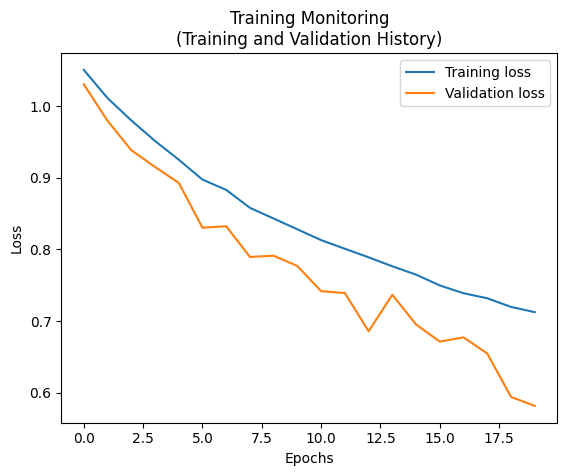

In [47]:
plt.plot(loss_tr, label='Training loss')
plt.plot(dev_loss, label='Validation loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Monitoring\n(Training and Validation History)')
plt.legend()
plt.show()

##### Fig 2. Pre-trained Embeddings

GloVe embeddings are pre-trained on a large corpus of text, often encompassing a broad section of the language or specialized domains. This pre-training allows the embeddings to capture different aspects of word usage and generalize better. It only focuses on learning task-specific patters and reduce training time significantly. 

The graph shows that the validation loss is lower than the training loss which signifies that the model does not overfit and model generalizes well to unseen data. We can see a smooth loss curve due to a smaller learning rate. Hence we use the grid search to find the best fit.  

In [48]:
preds_te = [np.argmax(forward_pass(x, W, dropout_rate=0.0)['y'] ) + 1
            for x,y in zip(X_te,Y_te)]

print('Accuracy:', accuracy_score(Y_te,preds_te))
print('Precision:', precision_score(Y_te,preds_te,average='macro'))
print('Recall:', recall_score(Y_te,preds_te,average='macro'))
print('F1-Score:', f1_score(Y_te,preds_te,average='macro'))

Accuracy: 0.8787541713014461
Precision: 0.8786712470350294
Recall: 0.8787142326272761
F1-Score: 0.8786211902910527


### Discuss how did you choose model hyperparameters ?


The embedding size is fixed to 300 as per the given input zip file. Hence, we adjust the learning rate over a range of values from 0.005 to 0.5 the same way as done before. Since the embeddings already capture a significant amount of information, the model requires a lower learning rate. The model performs well with a learning rate of 0.015 and a drop rate of 0.2 using the grid search technique to find the best parameters. As seen in the earlier graph, higher values of the learning rate causes the fluctuations in both the losses. Hence the chosen hyperparameters help us get an accuracy of 89% which is a good improvement from before. We Implement early stopping by assigning smaller number of epochs, crucial for preventing overfitting, especially when fine-tuning pre-trained embeddings. Since the model is already leveraging a significant amount of prior knowledge, overfitting is a real concern, and early stopping helps mitigate this risk. 

In [ ]:
learning_rate_list = [0.015, 0.05, 0.1]
drop_out_rate_list = [0.4, 0.2]
test_score = []
hyper_list = []
all_list = []
result = []

for lr in learning_rate_list:
    for drop in drop_out_rate_list:
        # Initialise the weights of your network 
        W = network_weights(vocab_size=len(vocab),embedding_dim=300,hidden_dim=[], num_classes=3, init_val = 0.1)
            #Replace the weigths of the embedding matrix with w_glove
        W[0] = w_glove
        W, loss_tr, dev_loss = SGD(X_tr,Y_tr,W,X_dev=X_dev, Y_dev=Y_dev,lr=lr, dropout = drop,freeze_emb=False,tolerance=0.01,epochs=10,print_progress=True)
   
        preds_te = [np.argmax(forward_pass(x, W, dropout_rate=0.0)['y'])+1 for x,y in zip(X_tr,train_label)]
        tr_f1 = f1_score(train_label,preds_te,average='macro')
            
        preds_te = [np.argmax(forward_pass(x, W, dropout_rate=0.0)['y'])+1 for x,y in zip(X_te,test_label)]
        accuracy = accuracy_score(test_label,preds_te)
        precision = precision_score(Y_te,preds_te,average='macro')
        Recall =recall_score(Y_te,preds_te,average='macro')
        F_Score =f1_score(Y_te,preds_te,average='macro')
        score = [accuracy, precision, Recall,F_Score]
            
        test_score.append(accuracy)
        all_list.append([accuracy, precision, Recall, F_Score])
        hyper = [dim, lr, drop]
        hyper_list.append(hyper)
        
        result.append({'learning_rate': lr, 'dropout_rate': drop, 'train_f1': tr_f1, 'test_accuracy': accuracy, 'test_precision': precision, 'test_recall': Recall, 'test_f1': F_Score})


In [46]:
hyper_list,  test_score

([[70, 0.015, 0.4],
  [70, 0.015, 0.2],
  [70, 0.05, 0.4],
  [70, 0.05, 0.2],
  [70, 0.1, 0.4],
  [70, 0.1, 0.2]],
 [0.8420467185761957,
  0.8909899888765295,
  0.8676307007786429,
  0.8553948832035595,
  0.8620689655172413,
  0.8743047830923248])

In [47]:
best_result = max(test_score)
best_id = test_score.index(best_result)
best_hyper = hyper_list[best_id]
best_S = all_list[best_id]
print("The best parameter and the F1-score on test set")
print("emb_dim:", best_hyper[0], " lr:", best_hyper[1]," drop_rate:" ,best_hyper[2] ," Accuracy:", best_result, "A/P/R/F",best_S)

The best parameter and the F1-score on test set
emb_dim: 70  lr: 0.015  drop_rate: 0.2  Accuracy: 0.8909899888765295 A/P/R/F [0.8909899888765295, 0.8907902068296661, 0.8909476031215161, 0.890808255853456]


  Learning Rate  | Drop Rate  | Accuracy
|:-:|:-:|:-:|
0.015| 0.4 |0.8865406006674083    |
0.015| 0.2 |0.8909899888765295  |
 0.05| 0.4  | 0.8698553948832035 |
0.5| 0.2|    0.8787541713014461   |
 0.1| 0.4 |  0.8731924360400445  |
 0.1| 0.2 |  0.864293659621802   |

# Extend to support deeper Architectures with more Hidden Layers

Extend the network to support back-propagation for more hidden layers. We modify the `backward_pass` function above to compute gradients and update the weights between intermediate hidden layers. Finally, train and evaluate a network with a deeper architecture.

In [ ]:
W = network_weights(vocab_size=len(vocab),embedding_dim=300,hidden_dim=[100,50],num_classes=3, init_val = 0.1)
W[0] = w_glove
for i in range(len(W)):
    print('Shape of W'+str(i), W[i].shape)
    
W, loss_tr, dev_loss = SGD(X_tr,Y_tr,W,X_dev=X_dev, Y_dev=Y_dev,lr= 0.05,dropout=0.2,freeze_emb=True,print_progress=True,
tolerance=0.00001,epochs=20)
#W, loss_tr, dev_loss = SGD(X_tr,Y_tr,W,X_dev=X_dev, Y_dev=Y_dev,lr=0.015,print_progress=True,
#                                       dropout = 0.2,freeze_emb = True,tolerance=0.01,epochs=20)

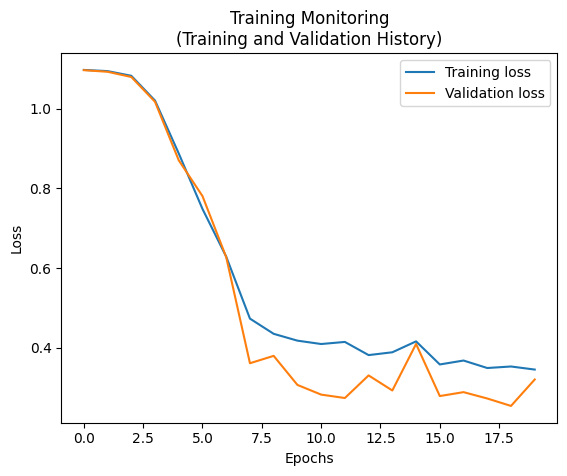

In [54]:
plt.plot(loss_tr, label='Training loss')
plt.plot(dev_loss, label='Validation loss')

plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.title('Training Monitoring\n(Training and Validation History)')
plt.legend()
plt.show()

In [55]:
preds_te = [np.argmax(forward_pass(x, W, dropout_rate=0.0)['y']) + 1
            for x,y in zip(X_te,Y_te)]

print('Accuracy:', accuracy_score(Y_te,preds_te))
print('Precision:', precision_score(Y_te,preds_te,average='macro'))
print('Recall:', recall_score(Y_te,preds_te,average='macro'))
print('F1-Score:', f1_score(Y_te,preds_te,average='macro'))

Accuracy: 0.8876529477196885
Precision: 0.8876496150843519
Recall: 0.8875771088814567
F1-Score: 0.8868045858945758


### Discuss how did you choose model hyperparameters ?

We choose the hyperparameters based on previous findings. We have observed that a learning rate of 0.015 gives good results. Deeper networks can learn a hierarchy of features. It combines these features into more complex combinations. Adding more layers increases the depth of non linear transformations that the data undergoes.  

In [ ]:
learning_rate_list = [0.015,0.05,0.01]
drop_out_rate_list = [0.2, 0.4]
test_score = []
hyper_list = []
all_list = []
result = []

for lr in learning_rate_list:
    for drop in drop_out_rate_list:
        W = network_weights(vocab_size=len(vocab),embedding_dim=300,hidden_dim=[20,100],num_classes=3, init_val = 0.1)
            #Replace the weigths of the embedding matrix with w_glove
        W[0] = w_glove
        W, loss_tr, dev_loss = SGD(X_tr,Y_tr,W,X_dev=X_dev, Y_dev=Y_dev,lr=lr,
                                   dropout = drop,freeze_emb=False,tolerance=0.1,epochs=5,print_progress=True)
        # Results and Scores
        preds_te = [np.argmax(forward_pass(x, W, dropout_rate=0.0)['y'])+1 for x,y in zip(X_te,test_label)]

        accuracy = accuracy_score(test_label,preds_te)
        precision = precision_score(Y_te,preds_te,average='macro')
        Recall =recall_score(Y_te,preds_te,average='macro')
        F_Score =f1_score(Y_te,preds_te,average='macro')
        score = [accuracy, precision, Recall,F_Score]

        test_score.append(accuracy)
        all_list.append([accuracy, precision, Recall, F_Score])
        hyper = [50, lr, drop]
        hyper_list.append(hyper)
        
        result.append({'learning_rate': lr, 'dropout_rate': drop,'test_accuracy': accuracy, 'test_precision': precision, 'test_recall': Recall, 'test_f1': F_Score})


In [93]:
best_result = max(test_score)
best_id = test_score.index(best_result)
best_hyper = hyper_list[best_id]
best_S = all_list[best_id]
print("The best parameter and the F1-score on test set")
print("emb_dim:", best_hyper[0], " lr:", best_hyper[1]," drop_rate:" ,best_hyper[2] ," Accuracy:", best_result, "A/P/R/F",best_S)

The best parameter and the F1-score on test set
emb_dim: 70  lr: 0.015  drop_rate: 0.2  Accuracy: 0.8553948832035595 A/P/R/F [0.8553948832035595, 0.8585693878872976, 0.8553994797473058, 0.8558058024192877]


## Full Results

| Model | Precision  | Recall  | F1-Score  | Accuracy
|:-:|:-:|:-:|:-:|:-:|
| Average Embedding  | 0.8630649395209075| 0.863125232255667| 0.8623202729442191|0.8631813125695217|
| Average Embedding (Pre-trained)  | 0.8907902068296661 | 0.8909476031215161 |0.890808255853456|0.8909899888765295|
| Average Embedding (Pre-trained) + X hidden layers    | 0.8585693878872976  | 0.8553994797473058  |  0.8558058024192877 |  0.8553948832035595 |



Please discuss why your best performing model is better than the rest.

The results of table clear show that the Average Embedding (Pre-trained) > Average Embedding (Pre-trained) + X hidden layers > Average Embedding.

This is reasonable result because Pre_trained model embedding W matrix was train by a large text corpus due to which it has better geralization ability and have a better initilization on model when trained. It has lesser training time and is more efficient in handling unseen data. The model makes use of transfer learning and requires less computaional resources and time compared to training word embeddings from scratch.  With the ue of optimal hyperparameters, the model successfully achieves an accuracy of over 89%.

Deeper architectures architectures has more layers can generate more detailed features. The additional layers provide a higher level of abstraction for the model, thus improving the ability of the model. However this may also have significant increase on the complexity. That may be the reason that we failed to have a large optimisation on grid search. 

Overall, each model was successful in achieving an accuracy greater than 85% which shows that model is effective and reliable.  